In [17]:
# =============================================================================
# DeepSeek Adoption Prediction: Complete SVM Pipeline (Robust + Visualizations)
# =============================================================================
# Features:
# - Robust auto-mapping for BI1..BI3 from survey headers
# - Robust auto-detection and renaming of UTAUT items to PE/EE/SI/FC/TR/PR 1..3
# - Resilient cleaning with non-null threshold + median imputation
# - LinearSVC (interpretable) with scaling
# - Visualizations:
#   1) Top 10 Log SVM Coefficients
#   2) Top 10 Odds Ratios
#   3) UTAUT Construct Importance (Sum |Coeff|)
#   4) UTAUT Construct Effect Directions (Mean Coeff)
#   5) SVM Confusion Matrix
#   6) SVM ROC Curve
#   7) SVM Performance Metrics Bar Chart
# - Optional k-fold CV snapshot (accuracy + ROC AUC)
# - CSV exports
# =============================================================================

# !pip install pandas numpy matplotlib seaborn scikit-learn

import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


In [19]:

# =============================================================================
# 1) Load CSV
# =============================================================================
CSV_PATH = '/content/DeepSeek by Engineering Students_SEM & ML-Final (Responses) - Form Responses 1.csv'
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

print(f"Loaded dataset: {CSV_PATH}")
print("Shape:", df.shape)


Loaded dataset: /content/DeepSeek by Engineering Students_SEM & ML-Final (Responses) - Form Responses 1.csv
Shape: (247, 30)


In [20]:
# =============================================================================
# 2) BI auto-detection and standardization to BI1..BI3, compute BI_avg, High_BI
# =============================================================================
def find_bi_columns(columns):
    patterns = [
        r'\bBI\b', r'Behavioral Intention', r'Behavioural Intention',
        r'Intention to use', r'\bintend\b', r'\bintending\b',
        r'\brecommend\b', r'will recommend', r'use regularly',
        r'willing to invest time', r'willing to learn', r'future use'
    ]
    scored = []
    for col in columns:
        text = col.lower()
        score = sum(1 for p in patterns if re.search(p, text, re.IGNORECASE))
        if re.search(r'\b1[89]\b|\b2[0-1]\b|19\.|20\.|21\.', col):
            score += 1
        if score > 0:
            scored.append((col, score))
    scored.sort(key=lambda x: x[1], reverse=True)
    return [c for c, _ in scored[:3]]

existing_bi = [c for c in ['BI1','BI2','BI3'] if c in df.columns]
if len(existing_bi) < 3:
    detected_bi = find_bi_columns(df.columns)
    detected_bi = list(dict.fromkeys(detected_bi))[:3]
    if len(detected_bi) == 3:
        bi_rename = {detected_bi[0]:'BI1', detected_bi[1]:'BI2', detected_bi[2]:'BI3'}
        print("ℹ️ Mapping detected BI columns:", bi_rename)
        df = df.rename(columns=bi_rename)
    else:
        print("❌ Could not auto-detect exactly 3 BI columns.")
        print("Please provide a manual rename_map for BI1..BI3 and re-run.")
        raise KeyError("BI columns not found. Please map to BI1/BI2/BI3.")

assert all(c in df.columns for c in ['BI1','BI2','BI3']), "BI1/BI2/BI3 missing after mapping."

# Map Likert text to numeric for BI if needed
likert_map = {'Strongly Disagree':1, 'Disagree':2, 'Neutral':3, 'Agree':4, 'Strongly Agree':5}
for c in ['BI1','BI2','BI3']:
    if df[c].dtype == 'object':
        df[c] = df[c].map(likert_map)

df['BI_avg'] = df[['BI1','BI2','BI3']].mean(axis=1)
df['High_BI'] = (df['BI_avg'] >= 4).astype(int)
print("✅ BI_avg and High_BI created.")

ℹ️ Mapping detected BI columns: {'20. I will recommend DeepSeek to my classmates. (আমি আমার সহপাঠীদের DeepSeek ব্যবহার করার পরামর্শ দেব)': 'BI1', '19. I intend to use DeepSeek regularly in the next semester. (আমি আগামী সেমিস্টারে নিয়মিতভাবে DeepSeek ব্যবহার করার পরিকল্পনা করছি)': 'BI2', '21. I am willing to invest time learning more about DeepSeek features. (আমি DeepSeek-এর ফিচারগুলো সম্পর্কে আরও জানতে সময় বিনিয়োগ করতে ইচ্ছুক)': 'BI3'}
✅ BI_avg and High_BI created.


In [21]:

# =============================================================================
# 3) UTAUT auto-detection: map survey headers to PE/EE/SI/FC/TR/PR (1..3)
# =============================================================================
patterns = {
    'PE': [
        r'performance expectancy', r'helps.*solve', r'improves.*performance',
        r'valuable insights', r'useful'
    ],
    'EE': [
        r'effort expectancy', r'easy to learn', r'intuitive', r'easy to use', r'effortless'
    ],
    'SI': [
        r'social influence', r'classmates encourage', r'instructors? recommend', r'influential people'
    ],
    'FC': [
        r'facilitating conditions', r'necessary resources', r'it support', r'training|documentation'
    ],
    'TR': [
        r'trust', r'reliable', r'consistent.*accurate', r'trust.*data'
    ],
    'PR': [
        r'perceived risk', r'worry.*data', r'concern.*errors', r'privacy', r'uncertain'
    ]
}

def score_match(col_text, regex_list):
    text = col_text.lower()
    score = 0
    for rgx in regex_list:
        if re.search(rgx, text, re.IGNORECASE):
            score += 1
    if re.search(r'\b[1-9]\.', col_text):
        score += 0.5
    return score

def top_k_matches(columns, regex_list, k=3, exclude=set()):
    scored = []
    for c in columns:
        if c in exclude:
            continue
        s = score_match(c, regex_list)
        if s > 0:
            scored.append((c, s))
    scored.sort(key=lambda x: x[1], reverse=True)
    return [c for c, _ in scored[:k]]

all_cols = list(df.columns)
used = set()
utaut_rename_map = {}

for construct, rgx in patterns.items():
    matches = top_k_matches(all_cols, rgx, k=3, exclude=used)
    if len(matches) == 3:
        utaut_rename_map[matches[0]] = f'{construct}1'
        utaut_rename_map[matches[1]] = f'{construct}2'
        utaut_rename_map[matches[2]] = f'{construct}3'
        used.update(matches)

print("Proposed UTAUT rename_map:")
for k, v in utaut_rename_map.items():
    print(f"  '{k}' -> {v}")

if not any(lbl[:2] in {'PE','EE','SI','FC','TR','PR'} for lbl in utaut_rename_map.values()):
    raise KeyError("Could not auto-detect UTAUT items. Provide manual mapping for PE/EE/SI/FC/TR/PR.")

df = df.rename(columns=utaut_rename_map)

required_groups = {
    'PE': ['PE1','PE2','PE3'],
    'EE': ['EE1','EE2','EE3'],
    'SI': ['SI1','SI2','SI3'],
    'FC': ['FC1','FC2','FC3'],
    'TR': ['TR1','TR2','TR3'],
    'PR': ['PR1','PR2','PR3'],
}
utaut_items_detected = []
for g, cols in required_groups.items():
    exist = [c for c in cols if c in df.columns]
    utaut_items_detected.extend(exist)

if len(utaut_items_detected) == 0:
    raise KeyError("No UTAUT items detected after renaming.")

print("Detected UTAUT items:", utaut_items_detected)

# Map Likert to numeric for all UTAUT items as needed
for col in utaut_items_detected:
    if df[col].dtype == 'object':
        df[col] = df[col].map(likert_map)

Proposed UTAUT rename_map:
  '1. DeepSeek helps me solve complex engineering problems more effectively. (DeepSeek আমাকে জটিল প্রকৌশল সমস্যা আরও কার্যকরভাবে সমাধান করতে সাহায্য করে)' -> PE1
  '2. Using DeepSeek improves my academic performance (e.g. grades). (DeepSeek ব্যবহার করার ফলে আমার একাডেমিক পারফরম্যান্স (যেমন: গ্রেড) উন্নত হয়)' -> PE2
  '3. DeepSeek provides valuable insights that I couldn’t easily get otherwise. (DeepSeek আমাকে এমন মূল্যবান অন্তর্দৃষ্টি প্রদান করে, যা অন্যভাবে সহজে পাওয়া সম্ভব নয়)' -> PE3
  '5. DeepSeek’s interface is intuitive. (DeepSeek-এর ইন্টারফেসটি সহজবোধ্য)' -> EE1
  '6. It is effortless to get DeepSeek to perform the tasks I need. (আমার প্রয়োজনীয় কাজগুলো করাতে DeepSeek ব্যবহার করা খুবই সহজ)' -> EE2
  '4. Learning to use DeepSeek is easy for me. (DeepSeek ব্যবহার করতে শেখা আমার জন্য সহজ)' -> EE3
  '7.  My classmates encourage me to use DeepSeek.(আমার সহপাঠীরা আমাকে DeepSeek ব্যবহার করতে উৎসাহিত করে)' -> SI1
  '8. Instructors recommend using DeepSeek 

In [22]:

# =============================================================================
# 4) Robust cleaning, imputation, and target checks
# =============================================================================
# Keep rows with >= 80% non-null UTAUT answers + valid BI target
min_non_null = max(1, int(0.8 * len(utaut_items_detected)))
row_valid_mask = df[utaut_items_detected].notna().sum(axis=1) >= min_non_null
target_ok = df[['BI1','BI2','BI3','BI_avg','High_BI']].notna().all(axis=1)

df_clean = df[row_valid_mask & target_ok].copy()
print(f"Rows after robust filtering: {len(df_clean)}")

if len(df_clean) == 0:
    print("⚠️ No rows remained after filtering. Suggestions:")
    print("  1) Lower non-null threshold from 80% to 60%")
    print("  2) Verify UTAUT auto-mapping patterns match your headers")
    raise ValueError("Empty dataset after cleaning.")

# Median impute any remaining missing in UTAUT items
for col in utaut_items_detected:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

X = df_clean[utaut_items_detected].copy()
y = df_clean['High_BI'].astype(int).copy()

if X.shape[0] == 0 or y.shape[0] == 0:
    raise ValueError("X or y empty after cleaning.")

if y.nunique() < 2:
    print("⚠️ Target has single class after filtering. Stratify disabled.")
    use_stratify = None
else:
    use_stratify = y

print(f"Final usable rows: {len(X)}, class balance:", y.value_counts().to_dict())


Rows after robust filtering: 247
Final usable rows: 247, class balance: {0: 171, 1: 76}


In [23]:

# =============================================================================
# 5) Split + scale
# =============================================================================
test_size = 0.2 if len(X) >= 50 else 0.15 if len(X) >= 30 else 0.25 if len(X) >= 10 else 0.33

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=use_stratify
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (197, 18), Test: (50, 18)


In [24]:
# =============================================================================
# 6) Train Linear SVM (interpretable)
# =============================================================================
svm_model = LinearSVC(random_state=42, penalty='l2', C=1.0, dual=False)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
# Decision function for ROC/AUC
y_score = svm_model.decision_function(X_test)


In [25]:
# =============================================================================
# 7) Metrics
# =============================================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_score)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print("\n=== SVM PERFORMANCE METRICS ===")
print(f"Accuracy     : {acc:.3f}")
print(f"Precision    : {prec:.3f}")
print(f"Recall       : {rec:.3f}")
print(f"Specificity  : {specificity:.3f}")
print(f"F1-Score     : {f1:.3f}")
print(f"ROC AUC      : {roc_auc:.3f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=['Low Intent (0)','High Intent (1)']))



=== SVM PERFORMANCE METRICS ===
Accuracy     : 0.760
Precision    : 0.600
Recall       : 0.600
Specificity  : 0.829
F1-Score     : 0.600
ROC AUC      : 0.720

Classification Report
                 precision    recall  f1-score   support

 Low Intent (0)       0.83      0.83      0.83        35
High Intent (1)       0.60      0.60      0.60        15

       accuracy                           0.76        50
      macro avg       0.71      0.71      0.71        50
   weighted avg       0.76      0.76      0.76        50



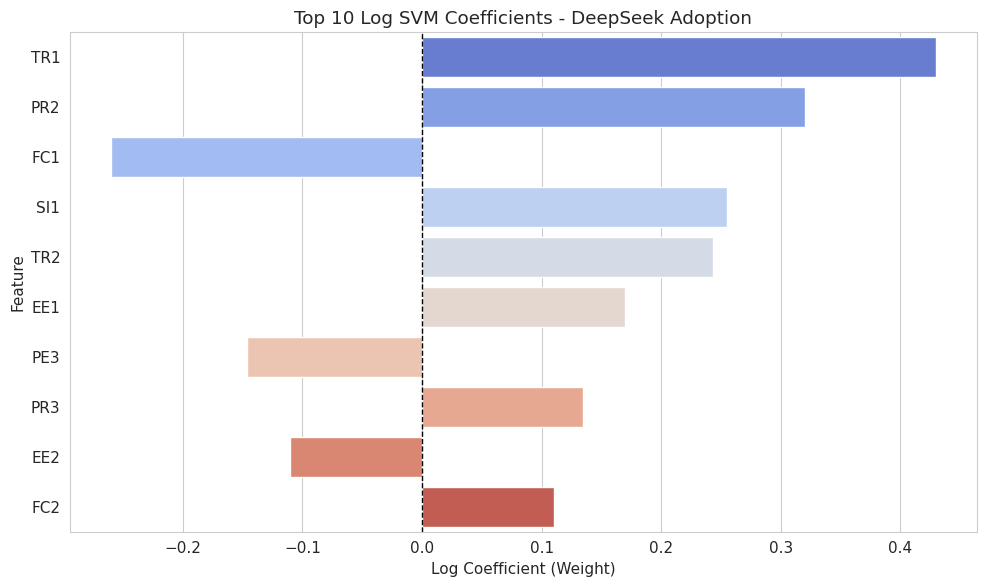

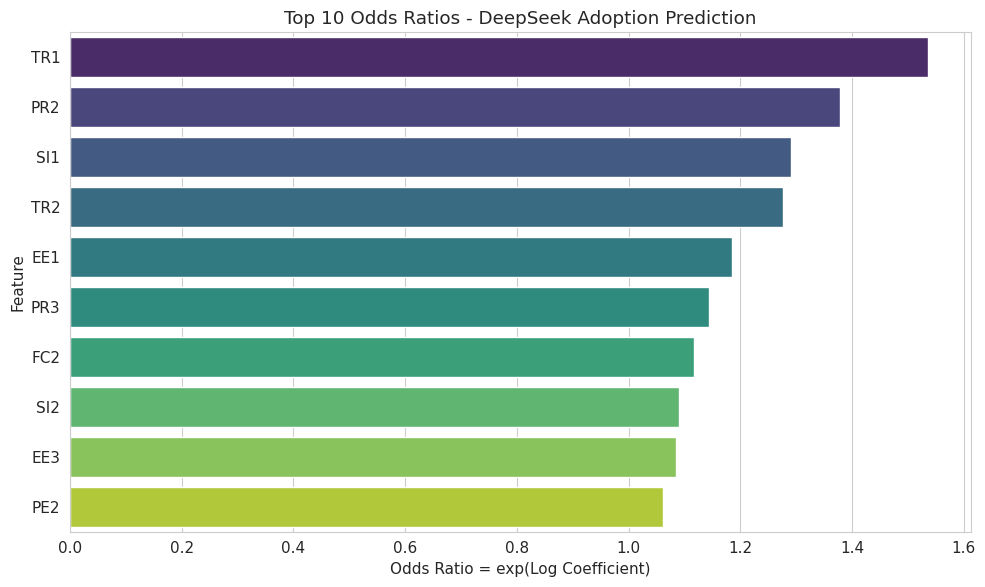

In [26]:
# =============================================================================
# 8) Coefficients, Odds Ratios, Top-10 plots
# =============================================================================
coef_df = pd.DataFrame({
    'Feature': list(X.columns),
    'Log_Coefficient': svm_model.coef_[0]
})
coef_df['Abs_Coefficient'] = coef_df['Log_Coefficient'].abs()
coef_df['Odds_Ratio'] = np.exp(coef_df['Log_Coefficient'])

top10_by_abs = coef_df.sort_values('Abs_Coefficient', ascending=False).head(10)
top10_or = coef_df.sort_values('Odds_Ratio', ascending=False).head(10)

# Top 10 log coefficients
plt.figure(figsize=(10,6))
sns.barplot(data=top10_by_abs, y='Feature', x='Log_Coefficient', palette='coolwarm')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Top 10 Log SVM Coefficients - DeepSeek Adoption")
plt.xlabel("Log Coefficient (Weight)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Top 10 odds ratios
plt.figure(figsize=(10,6))
sns.barplot(data=top10_or, y='Feature', x='Odds_Ratio', palette='viridis')
plt.title("Top 10 Odds Ratios - DeepSeek Adoption Prediction")
plt.xlabel("Odds Ratio = exp(Log Coefficient)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


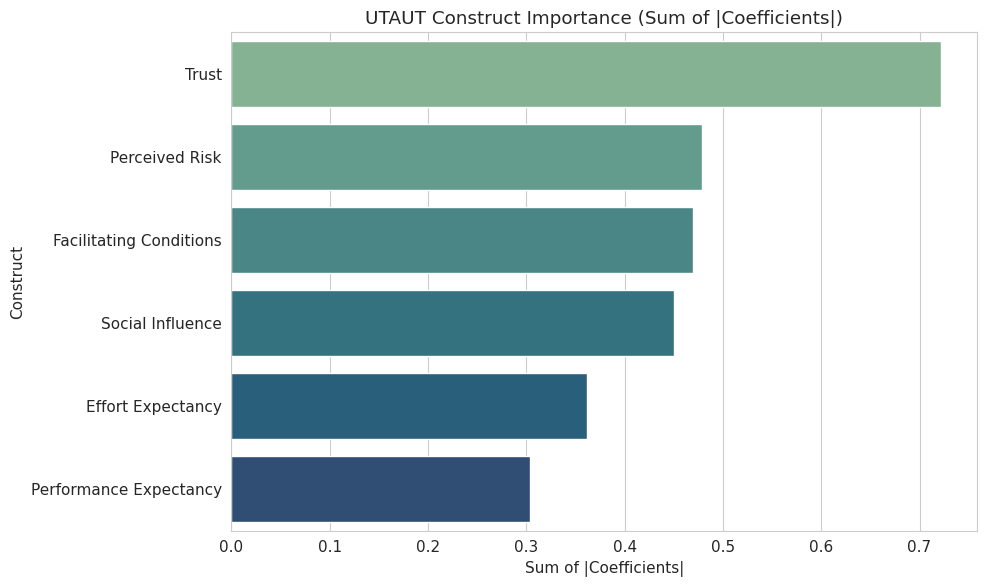

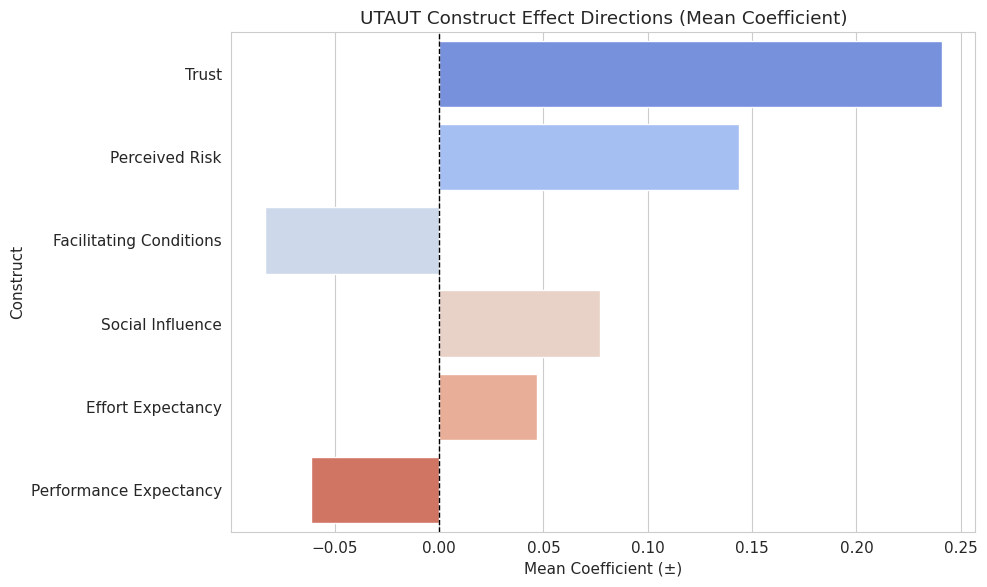

In [27]:
# =============================================================================
# 9) UTAUT Construct Importance and Effect Directions
# =============================================================================
construct_map = {
    'Performance Expectancy': ['PE1','PE2','PE3'],
    'Effort Expectancy'     : ['EE1','EE2','EE3'],
    'Social Influence'      : ['SI1','SI2','SI3'],
    'Facilitating Conditions': ['FC1','FC2','FC3'],
    'Trust'                 : ['TR1','TR2','TR3'],
    'Perceived Risk'        : ['PR1','PR2','PR3']
}

rows = []
for name, feats in construct_map.items():
    subset = coef_df[coef_df['Feature'].isin([f for f in feats if f in coef_df['Feature'].values])]
    if not subset.empty:
        total_abs = subset['Abs_Coefficient'].sum()
        mean_coeff = subset['Log_Coefficient'].mean()
        rows.append([name, total_abs, mean_coeff])

construct_df = pd.DataFrame(rows, columns=[
    'Construct', 'Importance (Sum |Coeff|)', 'Effect Direction (Mean Coeff)'
]).sort_values('Importance (Sum |Coeff|)', ascending=False)

# Importance
plt.figure(figsize=(10,6))
sns.barplot(data=construct_df, y='Construct', x='Importance (Sum |Coeff|)', palette='crest')
plt.title("UTAUT Construct Importance (Sum of |Coefficients|)")
plt.xlabel("Sum of |Coefficients|")
plt.ylabel("Construct")
plt.tight_layout()
plt.show()

# Effect direction
plt.figure(figsize=(10,6))
sns.barplot(data=construct_df, y='Construct', x='Effect Direction (Mean Coeff)', palette='coolwarm')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("UTAUT Construct Effect Directions (Mean Coefficient)")
plt.xlabel("Mean Coefficient (±)")
plt.ylabel("Construct")
plt.tight_layout()
plt.show()


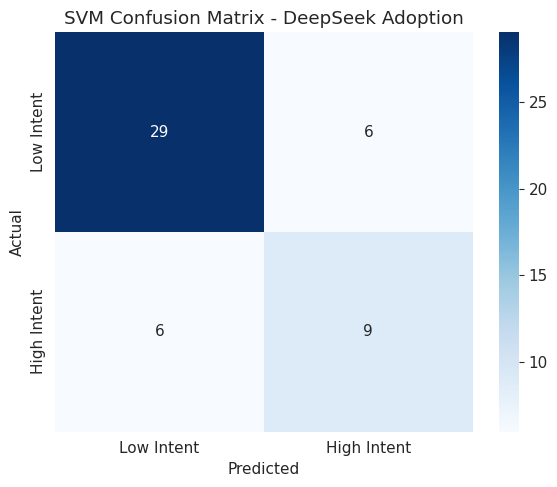

In [28]:
# =============================================================================
# 10) Confusion Matrix
# =============================================================================
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Intent','High Intent'],
            yticklabels=['Low Intent','High Intent'])
plt.title("SVM Confusion Matrix - DeepSeek Adoption")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()




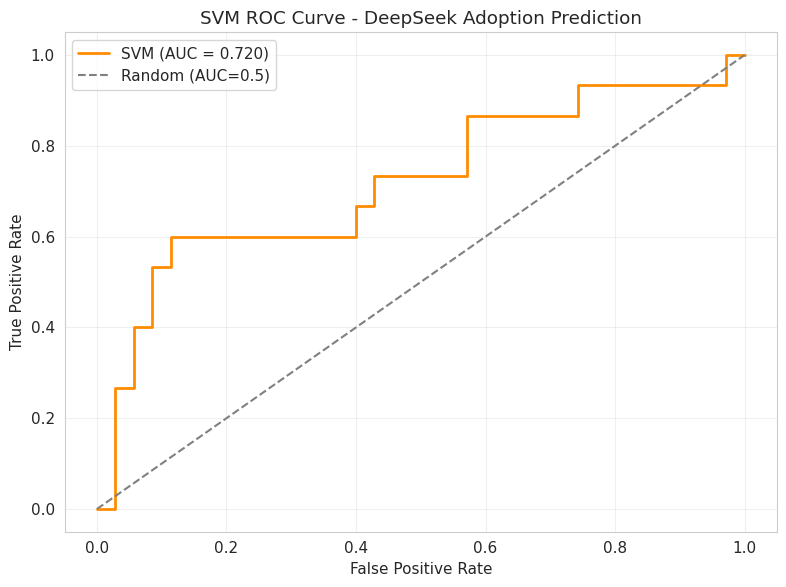

In [29]:

# =============================================================================
# 11) ROC Curve
# =============================================================================
fpr, tpr, thresholds = roc_curve(y_test, y_score)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f"SVM (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--', color='gray', label="Random (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve - DeepSeek Adoption Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

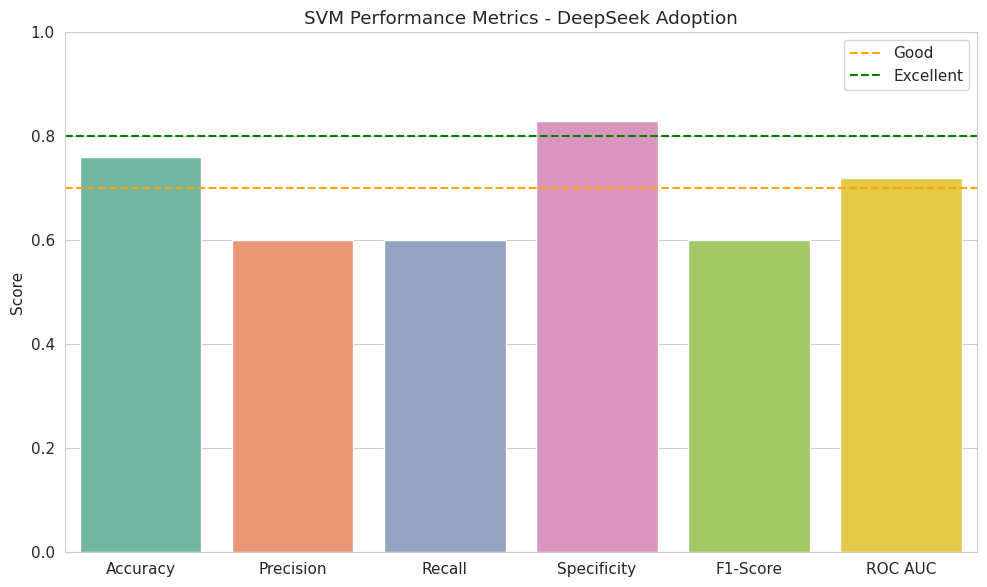

In [30]:
# =============================================================================
# 12) Performance Metrics Bar Chart
# =============================================================================
metrics = {
    'Accuracy'   : acc,
    'Precision'  : prec,
    'Recall'     : rec,
    'Specificity': specificity,
    'F1-Score'   : f1,
    'ROC AUC'    : roc_auc
}
plt.figure(figsize=(10,6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='Set2')
plt.title("SVM Performance Metrics - DeepSeek Adoption")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.axhline(0.7, color='orange', linestyle='--', label='Good')
plt.axhline(0.8, color='green', linestyle='--', label='Excellent')
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
# =============================================================================
# 13) Optional: cross-validation snapshot (Accuracy + ROC AUC)
# =============================================================================
try:
    svm_pipe = make_pipeline(StandardScaler(),
                             LinearSVC(random_state=42, penalty='l2', C=1.0, dual=False))
    cv_k = min(5, max(2, len(X)//5))
    cv_acc = cross_val_score(svm_pipe, X, y, cv=cv_k, scoring='accuracy')

    # For ROC AUC, need calibrated scores
    calibrated_pipe = make_pipeline(StandardScaler(),
                                    CalibratedClassifierCV(LinearSVC(random_state=42, dual=False), method='sigmoid', cv=3))
    cv_auc = cross_val_score(calibrated_pipe, X, y, cv=cv_k, scoring='roc_auc')

    print(f"\nCV ({cv_k}-fold) Accuracy: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
    print(f"CV ({cv_k}-fold) ROC AUC : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
except Exception as e:
    print("CV step skipped due to:", e)



CV (5-fold) Accuracy: 0.769 ± 0.052
CV (5-fold) ROC AUC : 0.783 ± 0.044


In [32]:
# =============================================================================
# 14) Save CSV artifacts
# =============================================================================
coef_df.to_csv("SVM_Coefficients_DeepSeek.csv", index=False)
construct_df.to_csv("SVM_UTAUT_Construct_Analysis.csv", index=False)
pd.DataFrame({'Actual':y_test.values, 'Predicted':y_pred, 'Score':y_score}).to_csv("SVM_Test_Predictions.csv", index=False)

print("\n✅ Completed SVM analysis and saved: ")
print("   - SVM_Coefficients_DeepSeek.csv")
print("   - SVM_UTAUT_Construct_Analysis.csv")
print("   - SVM_Test_Predictions.csv")


✅ Completed SVM analysis and saved: 
   - SVM_Coefficients_DeepSeek.csv
   - SVM_UTAUT_Construct_Analysis.csv
   - SVM_Test_Predictions.csv
